# PHASE 1 : PRÉPARATION DES DONNÉES

## 1. Importation et première inspection

* Chargement des bibliothèques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

* Chargement du dataset avec Pandas.

In [2]:
df = pd.read_csv('../data/framingham_heart_study.csv')
print(f"Dimensions : {df.shape}")

Dimensions : (4240, 16)


* Affichage des premières lignes du dataset.

In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


* Examen des informations générales du dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


* Statistiques descriptives du dataset.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


* Visualisation des proportions de la variable cible.

In [6]:
print("Distribution de TenYearCHD :")
print(df["TenYearCHD"].value_counts())
print()
print(df["TenYearCHD"].value_counts(normalize=True).round(3))

Distribution de TenYearCHD :
TenYearCHD
0    3596
1     644
Name: count, dtype: int64

TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64


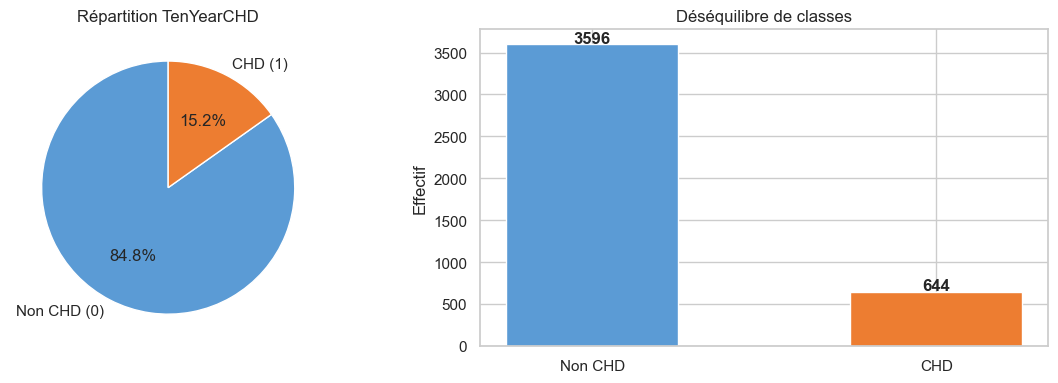

Ratio déséquilibre : 6 : 1
=> Classe déséquilibrée, on devra le gérer en modélisation


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["TenYearCHD"].value_counts()

axes[0].pie(counts, labels=["Non CHD (0)", "CHD (1)"],
            autopct="%1.1f%%", colors=["#5B9BD5", "#ED7D31"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[0].set_title("Répartition TenYearCHD")

axes[1].bar(["Non CHD", "CHD"], counts.values,
            color=["#5B9BD5", "#ED7D31"], edgecolor="white", width=0.5)
axes[1].set_title("Déséquilibre de classes")
axes[1].set_ylabel("Effectif")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Ratio déséquilibre : {counts[0]/counts[1]:.0f} : 1")
print("=> Classe déséquilibrée, on devra le gérer en modélisation")

## 2. Nettoyage des données

* Identifier et quantifier les valeurs manquantes.

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = missing.to_frame("count").assign(pourcentage=(missing / len(df) * 100).round(2))
print("Variables avec valeurs manquantes :")
print(missing_df)

Variables avec valeurs manquantes :
            count  pourcentage
glucose       388         9.15
education     105         2.48
BPMeds         53         1.25
totChol        50         1.18
cigsPerDay     29         0.68
BMI            19         0.45
heartRate       1         0.02


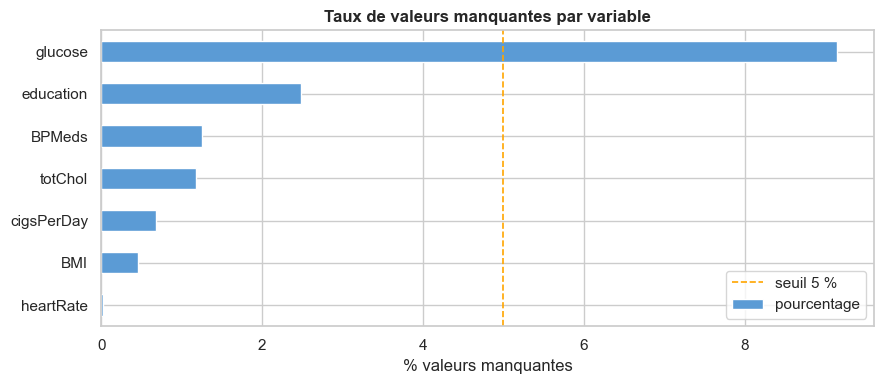

In [9]:
# graphe rapide pour visualiser les taux de manquants
fig, ax = plt.subplots(figsize=(9, 4))
missing_df["pourcentage"].sort_values().plot(kind="barh", ax=ax, color="#5B9BD5", edgecolor="white")
ax.axvline(5, color="orange", linestyle="--", lw=1.2, label="seuil 5 %")
ax.set_xlabel("% valeurs manquantes")
ax.set_title("Taux de valeurs manquantes par variable", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

* Définition et justification de la stratégie de traitement.

Le total des lignes présentant au moins une valeur manquante dépasse 5 % du dataset. La suppression entraînerait une perte trop importante, donc on préfère l'imputation.

- Variables catégorielles (`education`, `BPMeds`, `cigsPerDay`) → **mode**
- Variables numériques (`totChol`, `BMI`, `heartRate`, `glucose`) → **médiane** (plus robuste que la moyenne face aux valeurs extrêmes)

La Winsorisation est effectuée **avant** l'imputation pour que la médiane calculée ensuite ne soit pas influencée par les valeurs extrêmes.

* Traitement des valeurs aberrantes avant imputation (Winsorisation IQR).

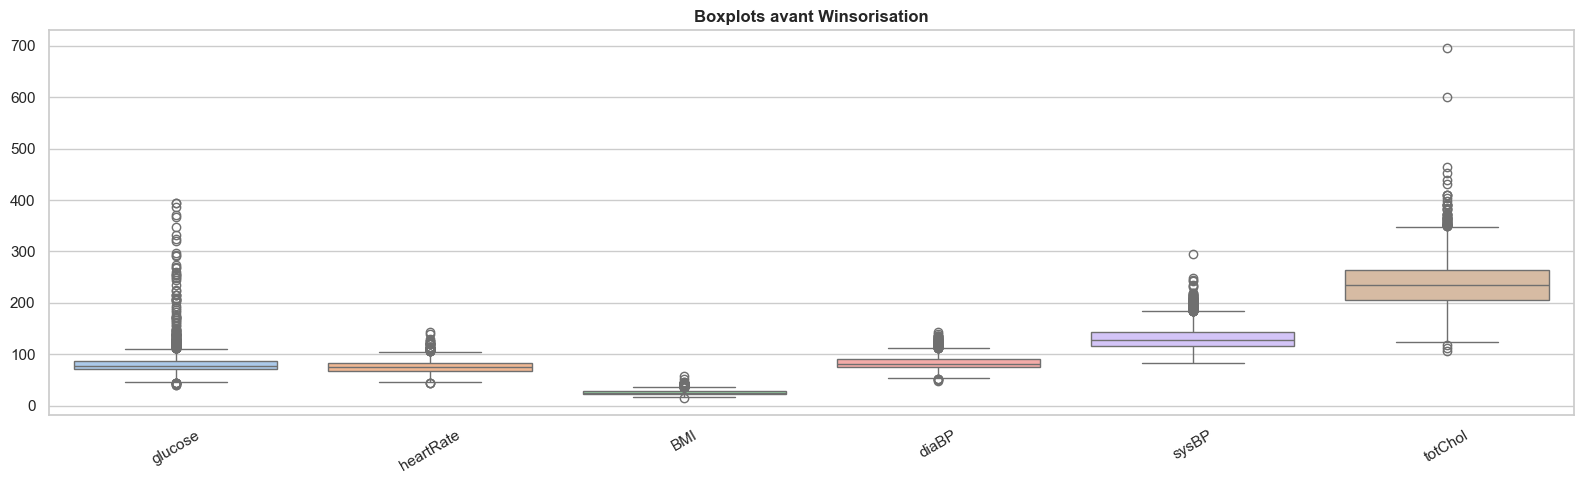

In [10]:
# on winsorise les colonnes numériques continues
# cigsPerDay est exclu car beaucoup de 0 (fume pas), pas adapté ici
colonnes_winso = ['glucose', 'heartRate', 'BMI', 'diaBP', 'sysBP', 'totChol']

plt.figure(figsize=(16, 5))
sns.boxplot(data=df[colonnes_winso], palette="pastel")
plt.title("Boxplots avant Winsorisation", fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

La Winsorisation est effectuée **avant** l'imputation pour que la médiane calculée ensuite ne soit pas influencée par les valeurs extrêmes. La variable `cigsPerDay` est exclue car sa distribution avec beaucoup de zéros ne se prête pas à ce traitement.

In [11]:
for col in colonnes_winso:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Winsorisation appliquée sur :", colonnes_winso)

Winsorisation appliquée sur : ['glucose', 'heartRate', 'BMI', 'diaBP', 'sysBP', 'totChol']


* Vérification des distributions des variables numériques avant imputation.

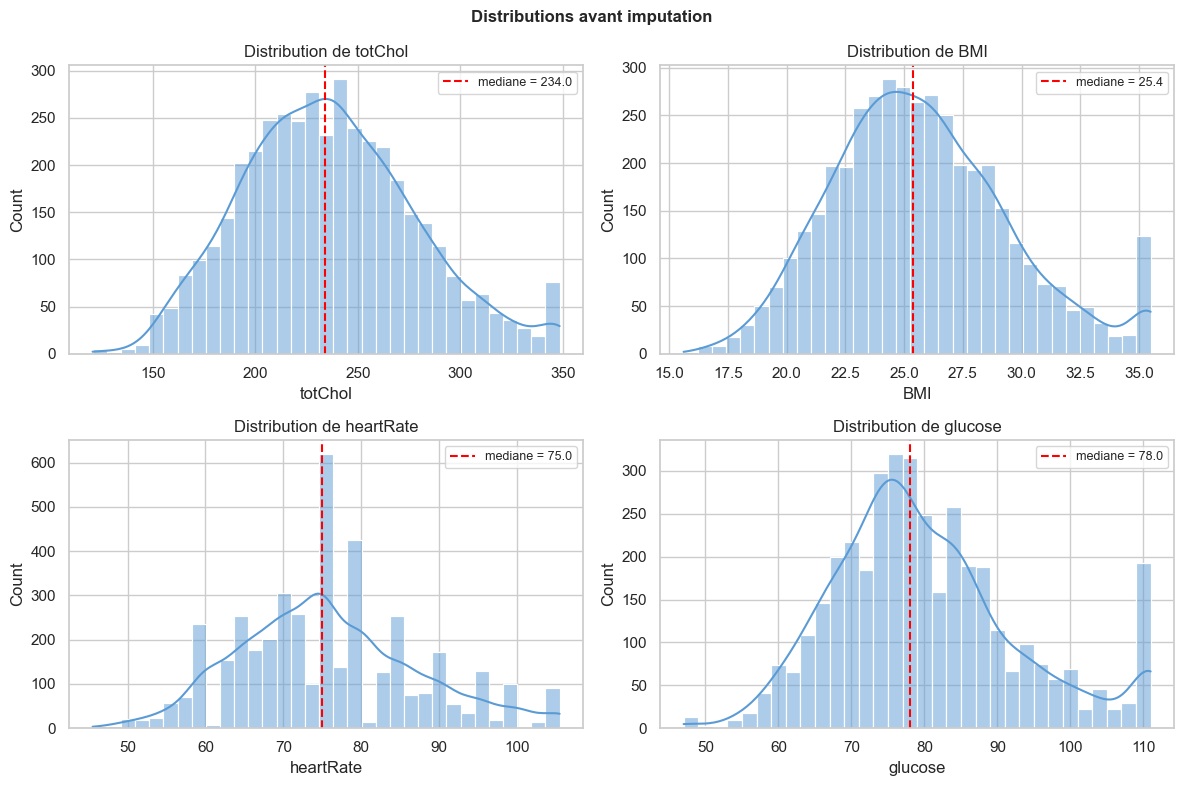

In [12]:
missing_col_num = ['totChol', 'BMI', 'heartRate', 'glucose']

# on regarde les distributions pour choisir la bonne valeur d'imputation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, feature in enumerate(missing_col_num):
    sns.histplot(df[feature].dropna(), kde=True, ax=axes[i], color="#5B9BD5")
    axes[i].axvline(df[feature].median(), color="red", linestyle="--",
                    lw=1.5, label=f"mediane = {df[feature].median():.1f}")
    axes[i].set_title(f"Distribution de {feature}")
    axes[i].legend(fontsize=9)
plt.suptitle("Distributions avant imputation", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

* Application de la stratégie d'imputation.

In [13]:
missing_col_cat = ['education', 'cigsPerDay', 'BPMeds']
missing_col_num = ['totChol', 'BMI', 'heartRate', 'glucose']

for col in missing_col_cat:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in missing_col_num:
    df[col] = df[col].fillna(df[col].median())

print("Valeurs manquantes restantes :", df.isnull().sum().sum())
print("=> Imputation terminée")

Valeurs manquantes restantes : 0
=> Imputation terminée


* Vérification et suppression des doublons.

In [14]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


* Visualisation des valeurs aberrantes après Winsorisation.

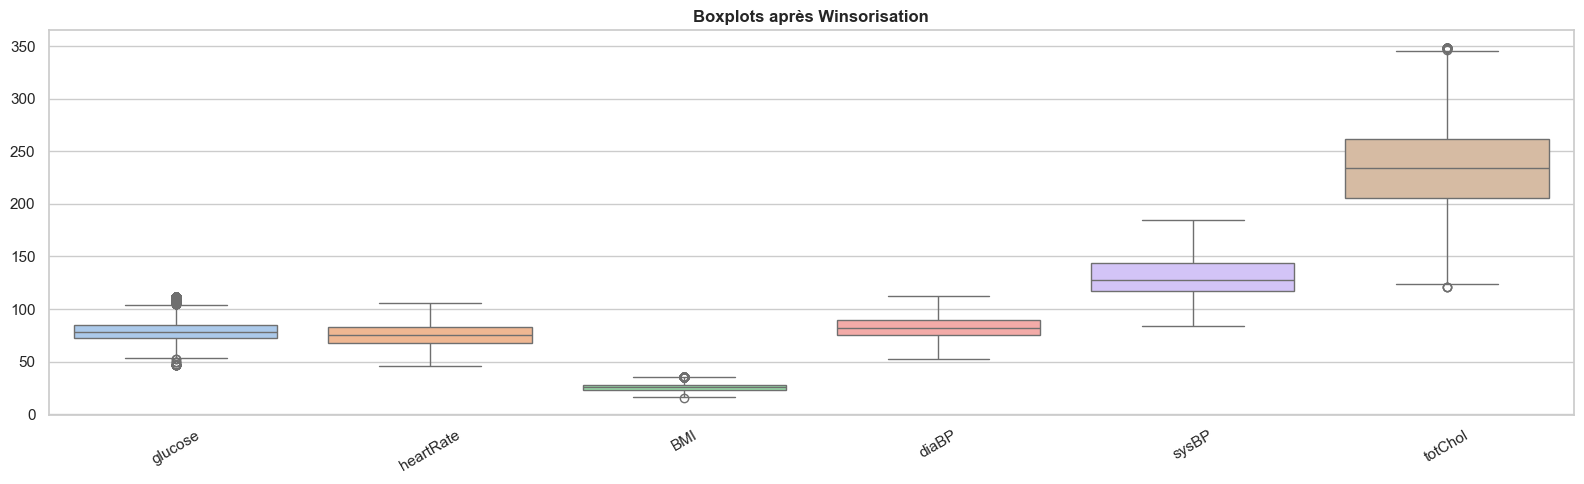

In [15]:
plt.figure(figsize=(16, 5))
sns.boxplot(data=df[colonnes_winso], palette="pastel")
plt.title("Boxplots après Winsorisation", fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

* Correction des types de données.

In [16]:
df["education"]  = df["education"].astype("int")
df["BPMeds"]     = df["BPMeds"].astype("int")
df["cigsPerDay"] = df["cigsPerDay"].astype("int")
print("Types corrigés :", ["education", "BPMeds", "cigsPerDay"])

Types corrigés : ['education', 'BPMeds', 'cigsPerDay']


## 3. Ingénierie des caractéristiques

Nous allons créer trois variables catégorielles dérivées de variables continues,
pertinentes d'un point de vue clinique pour la prédiction du risque cardiovasculaire
(IMC, tension artérielle, fréquence cardiaque), ainsi que des variables numériques
composites basées sur des interactions connues dans la littérature médicale.

* Création de la variable `BMI_Interpret`.

In [17]:
def interpret_bmi(bmi):
    if bmi < 18.5:
        return "Insuffisance ponderale"
    elif 18.5 <= bmi < 25:
        return "Corpulence normale"
    elif 25 <= bmi < 30:
        return "Surpoids"
    else:
        return "Obesite"

df["BMI_Interpret"] = df["BMI"].apply(interpret_bmi)
print("Répartition BMI_Interpret :")
print(df["BMI_Interpret"].value_counts())

Répartition BMI_Interpret :
BMI_Interpret
Corpulence normale        1870
Surpoids                  1774
Obesite                    539
Insuffisance ponderale      57
Name: count, dtype: int64


* Création de la variable `Tension`.

In [18]:
def interpret_tension(row):
    sys = row["sysBP"]
    dia = row["diaBP"]
    if sys < 120 and dia < 80:
        return "Normale"
    elif 120 <= sys <= 129 and dia < 80:
        return "Elevee"
    else:
        return "Hypertension"

df["Tension"] = df.apply(interpret_tension, axis=1)
print("Répartition Tension :")
print(df["Tension"].value_counts())

Répartition Tension :
Tension
Hypertension    2797
Normale         1033
Elevee           410
Name: count, dtype: int64


* Création de la variable `heartRate_Interpret`.

In [19]:
def interpret_heartRate(hr):
    if 60 <= hr <= 100:
        return "Normale"
    elif hr > 100:
        return "Tachycardie"
    else:
        return "Bradycardie"

df["heartRate_Interpret"] = df["heartRate"].apply(interpret_heartRate)
print("Répartition heartRate_Interpret :")
print(df["heartRate_Interpret"].value_counts())

Répartition heartRate_Interpret :
heartRate_Interpret
Normale        3929
Bradycardie     206
Tachycardie     105
Name: count, dtype: int64


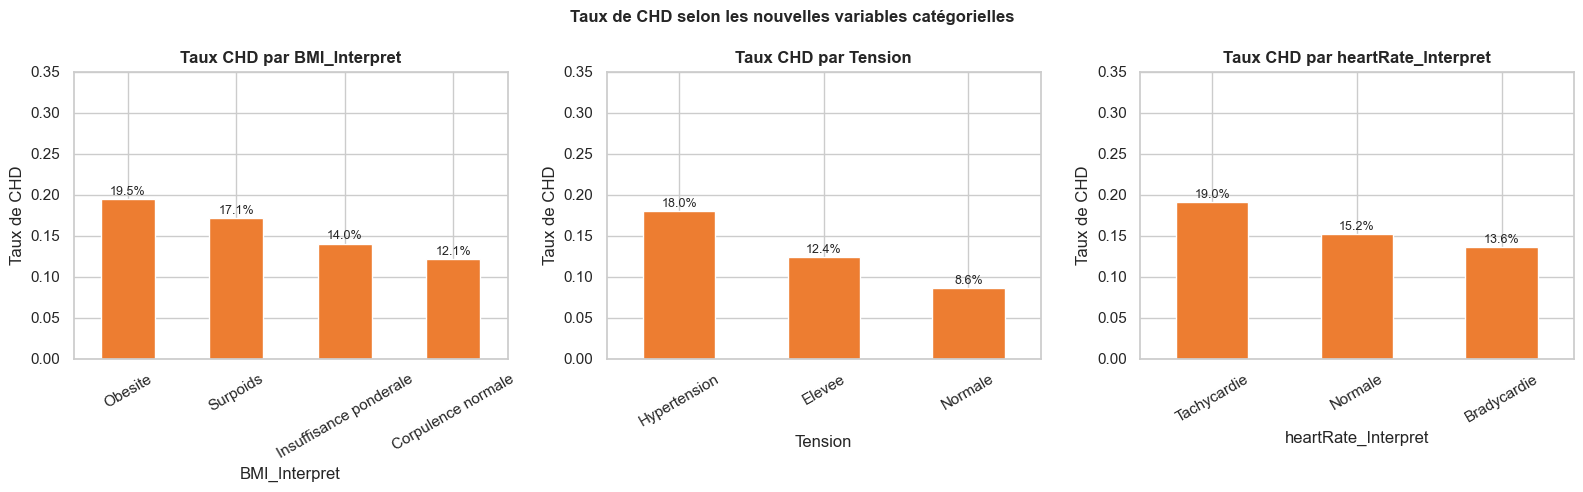

In [20]:
# on vérifie que les nouvelles variables sont bien liées à TenYearCHD
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["BMI_Interpret", "Tension", "heartRate_Interpret"]):
    taux = df.groupby(col)["TenYearCHD"].mean().sort_values(ascending=False)
    taux.plot(kind="bar", ax=ax, color="#ED7D31", edgecolor="white", rot=30)
    ax.set_title(f"Taux CHD par {col}", fontweight="bold")
    ax.set_ylabel("Taux de CHD")
    ax.set_ylim(0, 0.35)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.005,
                f"{p.get_height():.1%}", ha="center", fontsize=9)
plt.suptitle("Taux de CHD selon les nouvelles variables catégorielles",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

* Création de variables numériques composites.

In [21]:
# Score de risque composite : agrège les principaux facteurs de risque cardiovasculaire
df['risk_score'] = (
    (df['age'] > 55).astype(int) * 2 +
    (df['sysBP'] >= 140).astype(int) * 2 +
    (df['cigsPerDay'] > 0).astype(int) +
    (df['totChol'] > 240).astype(int) +
    (df['BMI'] >= 30).astype(int) +
    df['diabetes'].astype(int) +
    df['prevalentHyp'].astype(int)
)

# Pression pulsée : indicateur vasculaire (différence systolique - diastolique)
df['pulse_pressure'] = df['sysBP'] - df['diaBP']

# Interaction âge x pression systolique : risque cumulé avec l'âge
df['age_sysBP'] = df['age'] * df['sysBP']

# Interaction tabac x cholestérol
df['smoke_chol'] = df['cigsPerDay'] * df['totChol']

print("Variables composites créées :", ['risk_score', 'pulse_pressure', 'age_sysBP', 'smoke_chol'])

Variables composites créées : ['risk_score', 'pulse_pressure', 'age_sysBP', 'smoke_chol']


* Encodage des variables catégorielles créées.

Les variables catégorielles dérivées (`BMI_Interpret`, `Tension`, `heartRate_Interpret`)
sont encodées en variables indicatrices (one-hot encoding) avec suppression de la première
modalité pour éviter la multicolinéarité parfaite (`drop_first=True`).

In [22]:
df = pd.get_dummies(
    df,
    columns=["BMI_Interpret", "Tension", "heartRate_Interpret"],
    drop_first=True,
    dtype=int
)

print(f"Dimensions après encodage : {df.shape}")
df.info()

Dimensions après encodage : (4240, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   male                                  4240 non-null   int64  
 1   age                                   4240 non-null   int64  
 2   education                             4240 non-null   int64  
 3   currentSmoker                         4240 non-null   int64  
 4   cigsPerDay                            4240 non-null   int64  
 5   BPMeds                                4240 non-null   int64  
 6   prevalentStroke                       4240 non-null   int64  
 7   prevalentHyp                          4240 non-null   int64  
 8   diabetes                              4240 non-null   int64  
 9   totChol                               4240 non-null   float64
 10  sysBP                                 4240 no

* Vérification de la corrélation des nouvelles features avec la variable cible.

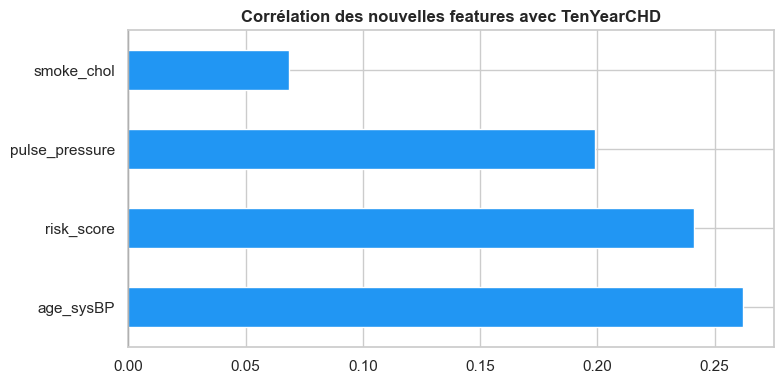

Feature la plus corrélée avec la cible : age_sysBP -> 0.262


In [23]:
new_feats = ['risk_score', 'pulse_pressure', 'age_sysBP', 'smoke_chol']
correlations = (
    df[new_feats + ['TenYearCHD']]
    .corr()['TenYearCHD']
    .drop('TenYearCHD')
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
correlations.plot(kind='barh',
                  color=['#2196F3' if x > 0 else '#f44336' for x in correlations],
                  edgecolor="white")
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Corrélation des nouvelles features avec TenYearCHD", fontweight="bold")
plt.tight_layout()
plt.show()

print("Feature la plus corrélée avec la cible :",
      correlations.idxmax(), "->", round(correlations.max(), 3))

* Exportation du dataset nettoyé.

In [24]:
df.to_csv("../data/framingham_heart_study_clean.csv", index=False)
print("Dataset exporté :", df.shape)
df.head()

Dataset exporté : (4240, 27)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,...,pulse_pressure,age_sysBP,smoke_chol,BMI_Interpret_Insuffisance ponderale,BMI_Interpret_Obesite,BMI_Interpret_Surpoids,Tension_Hypertension,Tension_Normale,heartRate_Interpret_Normale,heartRate_Interpret_Tachycardie
0,1,39,4,0,0,0,0,0,0,195.0,...,36.0,4134.0,0.0,0,0,1,0,1,1,0
1,0,46,2,0,0,0,0,0,0,250.0,...,40.0,5566.0,0.0,0,0,1,1,0,1,0
2,1,48,1,1,20,0,0,0,0,245.0,...,47.5,6120.0,4900.0,0,0,1,1,0,1,0
3,0,61,3,1,30,0,0,1,0,225.0,...,55.0,9150.0,6750.0,0,0,1,1,0,1,0
4,0,46,3,1,23,0,0,0,0,285.0,...,46.0,5980.0,6555.0,0,0,0,1,0,1,0
